# UniverSeg - Evaluation on Our Dataset

In [1]:
import torch
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
from UniverSeg.universeg import universeg
import sys
import itertools
from liver_metastasis_dataset import LiverTumorsDataset
import math
import matplotlib.pyplot as plt
import einops as E
import numpy as np

In [2]:
sys.path.append('UniverSeg')

First we will load the model and the dataset.

In [3]:
model = universeg(pretrained=True)
_ = model.to(device)
print(f"Running on device: {device}")

Running on device: cuda


In [ ]:
d_support = LiverTumorsDataset(split="support", label=1)
d_query = LiverTumorsDataset(split="query", label=1)
K = 10  # number of shots in support

 34%|███▍      | 37/109 [00:44<01:15,  1.05s/it]

In [5]:
support_images, support_labels = zip(*itertools.islice(d_support, K))
support_images = torch.stack(support_images).to(device)
support_labels = torch.stack(support_labels).to(device)

Now we will add some helper functions to visualize data and evaluate the model.

In [6]:
def visualize_tensors(tensors: torch.tensor, col_wrap: int=8, col_names: str=None, title: str=None):
    M = len(tensors)
    N = len(next(iter(tensors.values())))

    cols = col_wrap
    rows = math.ceil(N/cols) * M

    d = 2.5
    fig, axes = plt.subplots(rows, cols, figsize=(d*cols, d*rows))
    if rows == 1:
      axes = axes.reshape(1, cols)

    for g, (grp, tensors) in enumerate(tensors.items()):
        for k, tensor in enumerate(tensors):
            col = k % cols
            row = g + M*(k//cols)
            x = tensor.detach().cpu().numpy().squeeze()
            ax = axes[row,col]
            if len(x.shape) == 2:
                ax.imshow(x,vmin=0, vmax=1, cmap='gray')
            else:
                ax.imshow(E.rearrange(x,'C H W -> H W C'))
            if col == 0:
                ax.set_ylabel(grp, fontsize=16)
            if col_names is not None and row == 0:
                ax.set_title(col_names[col])

    for i in range(rows):
        for j in range(cols):
            ax = axes[i,j]
            ax.grid(False)
            ax.set_xticks([])
            ax.set_yticks([])

    if title:
        plt.suptitle(title, fontsize=20)

    plt.tight_layout()

In [9]:
# Dice metric for measuring volume agreement
def dice_score(y_pred: torch.Tensor, y_true: torch.Tensor) -> float:
    y_pred = y_pred.long()
    y_true = y_true.long()
    score = 2*(y_pred*y_true).sum() / (y_pred.sum() + y_true.sum())
    return score.item()

Now we will run the inference model on the query images

In [25]:
# select an image, label test pair
idx = np.random.permutation(len(d_query))[0]
image, label = d_query[idx]
image, label = image.to(device), label.to(device)

# run inference
logits = model(image[None].type(torch.float), support_images[None].type(torch.float), support_labels[None].type(torch.float))[0].to(device)
pred = torch.sigmoid(logits)

# visualize
res = {'data': [image, label, pred, pred > 0.5]}
titles = col_names=['image', 'label', 'pred (soft)', 'pred (hard)']
visualize_tensors(res, col_wrap=4, col_names=titles)

RuntimeError: Given groups=1, weight of size [64, 3, 3, 3], expected input[1, 21, 256, 256] to have 3 channels, but got 21 channels instead

In [22]:
print(image[None][None].dtype)
print(support_labels[None][None].dtype)
print(support_images[None][None].dtype)

torch.float64
torch.float64
torch.float64


In [13]:
d_support[0]

torch.Size([256, 256, 1])

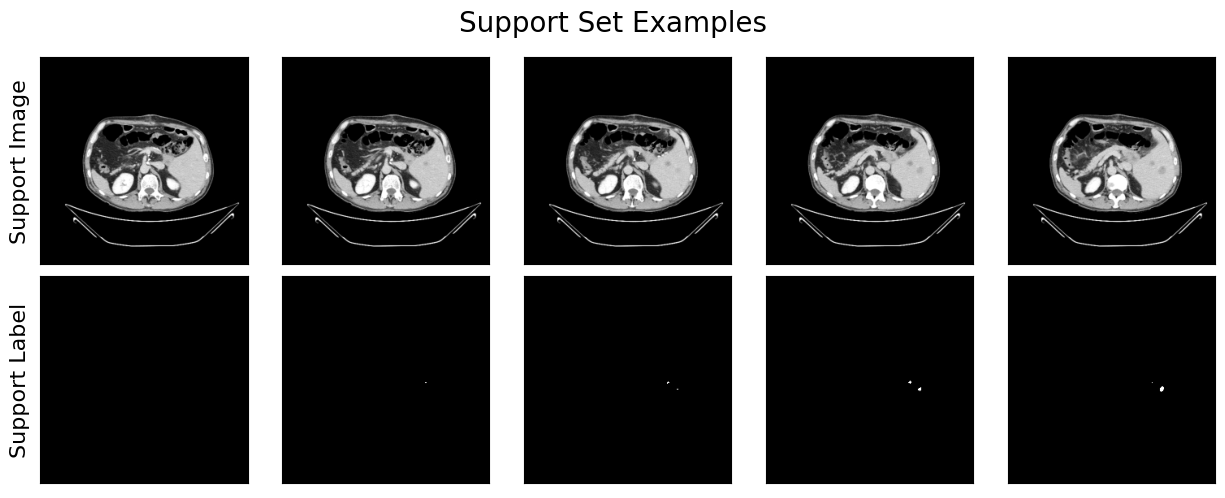

In [10]:
rng = range(15,20)
support_images, support_labels = [d_support[i][0] for i in rng], [d_support[i][1] for i in rng]
n_viz = 5
visualize_tensors({
    'Support Image': support_images[:n_viz],
    'Support Label': support_labels[:n_viz],
}, col_wrap=5, title='Support Set Examples')